In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="openai/gpt-oss-20b")
result=llm.invoke("Hey!!")
result

d:\agenticai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AIMessage(content='Hey there! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hey!!". We need to respond in a friendly manner. Probably ask how we can help.'}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 73, 'total_tokens': 118, 'completion_time': 0.065496702, 'completion_tokens_details': {'reasoning_tokens': 24}, 'prompt_time': 0.005262198, 'prompt_tokens_details': None, 'queue_time': 0.286029358, 'total_time': 0.0707589}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_ef00694abe', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f94e8-19e6-7722-b42a-6f3cc8795b3f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 45, 'total_tokens': 118, 'output_token_details': {'reasoning': 24}})

In [3]:
from typing import Annotated, List
import operator
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage
from typing_extensions import TypedDict

class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str

In [4]:
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not.",
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it.",
    )

evaluator = llm.with_structured_output(Feedback)

In [5]:
def llm_call_generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}

def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}

def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"


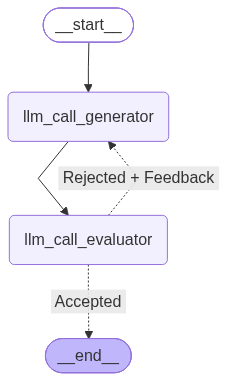

In [7]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

optimizer_builder = StateGraph(State)

optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

optimizer_workflow = optimizer_builder.compile()
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

In [8]:
state = optimizer_workflow.invoke({"topic": "Agentic AI system"})
print(state["joke"])

Why did the agentic AI bring a suitcase to the office?

Because it heard the job description said “take charge” and it wanted to be prepared for a *full* trip!
